# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch. 

| Groep: 54     |  |
| :-------------|:-------------|
| Nina Gumbs| 6552544|
| Kristy Workel| 6483984|
| Aimee Hoefnagel| 5821711 |

| Planning Groep: 54    |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Criteria opgesteld | 11:45 |
| Mijlpaal 2: Eerste kalibratie meting gedaan| 14:00 |
| Pauze 1| 12:45-13:45 |
| Pauze 2| 15:30 - 15:45 |

## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![Alt](schets.jpeg "analyse: ideeen")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Thermistar | Bepalen of iemand koorts heeft | Nauwkeurig op 0.25 graad|
|Thermistar | Bepalen of iemand koorts heeft | Bereik tussen 35 en 45 graden celsius|
|Thermistar | Bepalen of iemand koorts heeft | Bevat geen schadelijke stoffen voor het menselijk lichaam |
|LDR | Alarm als groenten te veel of te weinig licht krijgen | 1000 lux nauwkeurig kunnen meten|
|LDR | Alarm als groenten te veel of te weinig licht krijgen | Bereik tussen 10000 en 100000 lux |
|LDR | Alarm als groenten te veel of te weinig licht krijgen | Waterbestendig |
|Krachtmeter | Wc rol bewaarkoker sensor waarbij een lichtje gaat branden als er te weinig rollen zijn| Nauwkeurigheid van 0.5 Newton|
|Krachtmeter | Wc rol bewaarkoker sensor waarbij een lichtje gaat branden als er te weinig rollen zijn| Bereik tussen 0 en 4 Newton|
|Krachtmeter | Wc rol bewaarkoker sensor waarbij een lichtje gaat branden als er te weinig rollen zijn | Bestendig tegen de druk van 8 Newton|

Groep 54 heeft gekozen voor sensor krachtmeter. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Licht kort toe wat er in de foto te zien is.
 ![Alt](schets2.jpeg "schets student")

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? 
de hoeveelheid water in de fles, daarmee indirect het gewicht
2. Over welk bereik ga je deze variabelen veranderen?
Tussen 100 gram en 400 gram
3. Wat ga je allemaal meten?
Het gewicht en wat de Arduino geeft
4. Hoeveel metingen ga je doen?
14 met intervallen van ongeveer 25 gram
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?
Ja, want als je de fles vervangt voor gewoon een houder met wc rollen krijg je in principe precies de opstelling vertaalt naar de echte wereld. Met de metingen die we gaan doen kunnen we de onzekerheid bepalen, en bekijken of deze binnen ons criterium valt. 


## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.
We tapen het breadboard vast aan de tafel voor stabiliteit, waarbij de druksensor uit steekt. Deze laten we ondersteunen door een ook vastgeplakte kurk met dezelfde diameter als de sensor. op We gebruiken een op de kop gekeerde fles waar we telkens het water in laten varieren qua gewicht. Op de dop plakken we een kort stukje hout vast, met een kleiner oppervlakte dan de sensor, zodat de druk op het midden van de sensor zit. 
Metingen: we vullen telkens de fles met ongeveer 25 mL extra water, en wegen deze daarna. Elke meting herhalen we drie keer om de onzekerheid te verkleinen, ook omdat we de fles lichterlijk moeten ondersteunen wat de metingen kan verstoren. Dit zetten we om in Newton door F=mg. Dan plaatsen we de fles op de sensor en noteren we de meetwaarden uit arduino. Met deze gegevens wordt een fit gemaakt. 
 ![Alt](schets3.jpeg "meetopstelling student")

## *Opdracht 6*: Meten en fitten, Leerdoel

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit

gewichten = np.array([122.67,154.3,178.1,208,226.02,252.9,276.5,306,325.8,348.03,378.33,403.07,422.40,452.46])*9.81/1000

sensor1 = np.array([
    np.mean([13, 17, 16, 12, 15]),
    np.mean([10, 14, 14, 15, 17]),
    np.mean([20, 18, 19, 20, 18]),
    np.mean([20, 19, 18, 17, 21]),
    np.mean([20, 18, 21, 22, 26]),
    np.mean([22, 26, 25, 22, 26]),
    np.mean([26, 28, 30, 29, 32]),
    np.mean([32, 26, 30, 30, 30]),
    np.mean([34, 35, 33, 30, 31]),
    np.mean([34, 30, 30, 33, 33]),
    np.mean([34, 34, 34, 34, 35]),
    np.mean([39, 36, 37, 37, 37]),
    np.mean([37, 36, 36, 36, 36]),
    np.mean([39, 37, 40, 40, 41])
])

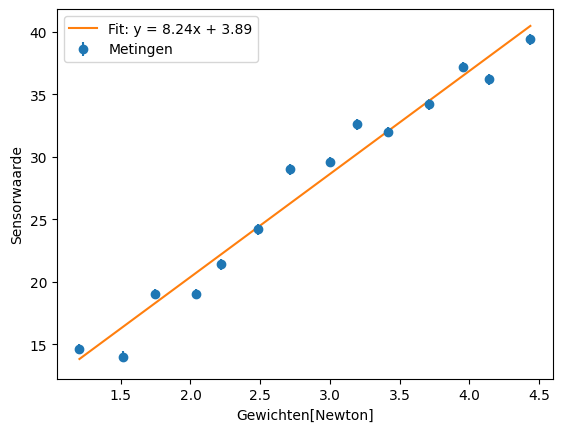

In [ ]:
# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.

# Model
def model(gewichten, a, b):
    return a * gewichten + b

# Fit
popt, pcov = curve_fit(model, gewichten, sensor1)
a, b = popt

# Fitlijn
x_fit = np.linspace(min(gewichten), max(gewichten), 100)
y_fit = model(x_fit, a, b)

# x-error
y_err = np.std(sensor1)/np.sqrt(sum(sensor1))
#y_err = np.array([np.std(m)/np.sqrt(len(m)) for m in metingen])

# Plot metingen
plt.errorbar(gewichten, sensor1, yerr=y_err, fmt='o', label="Metingen")

# Fitlijn
plt.plot(x_fit, y_fit, label=f"Fit: y = {a:.2f}x + {b:.2f}")

plt.xlabel("Gewichten[Newton]")
plt.ylabel("Sensorwaarde")
plt.legend()
plt.show()


## *Opdracht 7*: Iteratie nodig?

Nee, een iteratie is niet nodig. Er is namelijk een duidelijke trend te zien in de grafiek. Wij hebben wel kleine iteraties gedaan in het begin en hebben toen de meetopstelling verbeteerd, dus nu is het niet meer nodig. We hebben namelijk toen onder de sensor een scherpe verhoging geplaatst, wij hebben gebruikt gemaakt van een thermistar, waardoor de metingen veel nauwkeuriger werden. Er valt nu een duidelijke conclusie te trekken.

## *Opdracht 8*: Conclusie, leerdoel

De sensor is bestend tegen 8N druk en dekt het bereik (0-4N). Voor het laatste criterium zien we een fit-onzekerheid (0.42N) lager dan 0.5N, maar in de grafiek zien we grote spreiding en dus zijn individuele metingen onbetrouwbaar. Voor onze toepassing zou een gevoeligere sensor daarom gewenst zijn.

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.
## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.
We tapen het breadboard vast aan de tafel voor stabiliteit, waarbij de druksensor uit steekt. Deze laten we ondersteunen door een ook vastgeplakte kurk met dezelfde diameter als de sensor. op We gebruiken een op de kop gekeerde fles waar we telkens het water in laten varieren kwa gewicht. Op de dop plakken we een kort stukje hout vast, met een kleiner oppervlakte dan de sensor, zodat de druk op het midden van de sensor zit. 
Metingen: we vullen telkens de fles met ongeveer 25 mL extra water, en wegen deze daarna. Dit zetten we om in Newton door F=mg. Dan plaatsen we de fles op de sensor en noteren we de meetwaarden uit arduino. Met deze gegevens wordt een fit gemaakt. 
 ![Alt](schets3.jpeg "meetopstelling student")

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.
## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Thermistar | Bepalen of iemand koorts heeft | Nauwkeurig op 0.25 graad|
|Thermistar | Bepalen of iemand koorts heeft | Bereik tussen 35 en 45 graden celsius|
|Thermistar | Bepalen of iemand koorts heeft | Bevat geen schadelijke stoffen voor het menselijk lichaam |
|LDR | Alarm als groenten te veel of te weinig licht krijgen | 1000 lux nauwkeurig kunnen meten|
|LDR | Alarm als groenten te veel of te weinig licht krijgen | Bereik tussen 10000 en 100000 lux |
|LDR | Alarm als groenten te veel of te weinig licht krijgen | Waterbestendig |
|Krachtmeter | Wc rol bewaarkoker sensor waarbij een lichtje gaat branden als er te weinig rollen zijn| Nauwkeurigheid van 0.5 Newton|
|Krachtmeter | Wc rol bewaarkoker sensor waarbij een lichtje gaat branden als er te weinig rollen zijn| Bereik tussen 0 en 4 Newton|
|Krachtmeter | Wc rol bewaarkoker sensor waarbij een lichtje gaat branden als er te weinig rollen zijn | Bestendig tegen de druk van 8 Newton|

Groep 54 heeft gekozen voor sensor krachtmeter. 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.



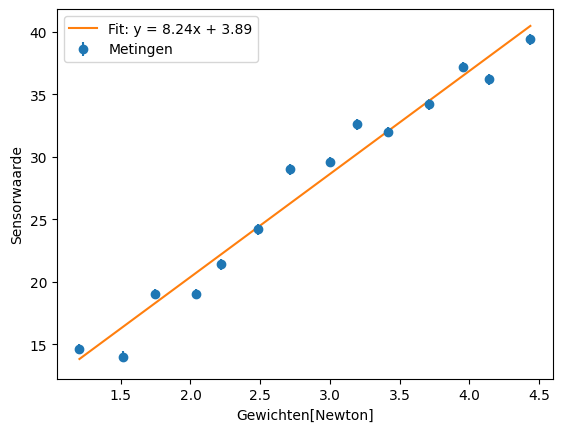

In [ ]:
# Zet hier jouw data in een voor jou handig formaat
import numpy as np
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit

gewichten = np.array([122.67,154.3,178.1,208,226.02,252.9,276.5,306,325.8,348.03,378.33,403.07,422.40,452.46])*9.81/1000

sensor1 = np.array([
    np.mean([13, 17, 16, 12, 15]),
    np.mean([10, 14, 14, 15, 17]),
    np.mean([20, 18, 19, 20, 18]),
    np.mean([20, 19, 18, 17, 21]),
    np.mean([20, 18, 21, 22, 26]),
    np.mean([22, 26, 25, 22, 26]),
    np.mean([26, 28, 30, 29, 32]),
    np.mean([32, 26, 30, 30, 30]),
    np.mean([34, 35, 33, 30, 31]),
    np.mean([34, 30, 30, 33, 33]),
    np.mean([34, 34, 34, 34, 35]),
    np.mean([39, 36, 37, 37, 37]),
    np.mean([37, 36, 36, 36, 36]),
    np.mean([39, 37, 40, 40, 41])
])

# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.

# Model
def model(gewichten, a, b):
    return a * gewichten + b

# Fit
popt, pcov = curve_fit(model, gewichten, sensor1)
a, b = popt

# Fitlijn
x_fit = np.linspace(min(gewichten), max(gewichten), 100)
y_fit = model(x_fit, a, b)

# x-error
y_err = np.std(sensor1)/np.sqrt(sum(sensor1))
#y_err = np.array([np.std(m)/np.sqrt(len(m)) for m in metingen])

# Plot metingen
plt.errorbar(gewichten, sensor1, yerr=y_err, fmt='o', label="Metingen")

# Fitlijn
plt.plot(x_fit, y_fit, label=f"Fit: y = {a:.2f}x + {b:.2f}")

plt.xlabel("Gewichten[Newton]")
plt.ylabel("Sensorwaarde")
plt.legend()
plt.show()


## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.
We tapen het breadboard vast aan de tafel voor stabiliteit, waarbij de druksensor uit steekt. Deze laten we ondersteunen door een ook vastgeplakte kurk met dezelfde diameter als de sensor. op We gebruiken een op de kop gekeerde fles waar we telkens het water in laten varieren kwa gewicht. Op de dop plakken we een kort stukje hout vast, met een kleiner oppervlakte dan de sensor, zodat de druk op het midden van de sensor zit. 
Metingen: we vullen telkens de fles met ongeveer 25 mL extra water, en wegen deze daarna. Elke meting herhalen we drie keer om de onzekerheid te verkleinen, ook omdat we de fles lichterlijk moeten ondersteunen wat de metingen kan verstoren. Dit zetten we om in Newton door F=mg. Dan plaatsen we de fles op de sensor en noteren we de meetwaarden uit arduino. Met deze gegevens wordt een fit gemaakt. 
 ![Alt](schets3.jpeg "meetopstelling student")

## *Opdracht 8*: Conclusie, leerdoel

De sensor is bestend tegen 8N druk en dekt het bereik (0-4N). Voor het laatste criterium zien we een fit-onzekerheid (0.42N) lager dan 0.5N, maar in de grafiek zien we grote spreiding en dus zijn individuele metingen onbetrouwbaar. Voor onze toepassing zou een gevoeligere sensor daarom gewenst zijn.